# Simulated IRFs from True VAR Model

This code creates simulated time series data where the underlying process is a VAR model, in order to asses the accuracy of LPs & SPLs when the true process is follows a VAR structure. The underlying VAR model uses randomly generated coefficients and is of order $O$ with $V$ variables.

In [1]:
# import packages
import statsmodels as sm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

In [15]:
# set parameters
q = 20 # number of periods for IRF
T = 100 # number of periods for simulated data
O = 4 # VAR order
V = 3 # number of variables in VAR

np.random.seed(3891) # set seed for reproducibility

### Generating observed data

In [16]:
# simulate data from VAR process based on parameters and random coefficients
A = np.random.uniform(low = -0.25, high = 0.25, size=(O, V, V)) # VAR coefficients

I = np.zeros((O, V)) # initial periods of data

observed_data = np.zeros((T+O, V))
for t in range(0, T+O):
    if t < O:
        observed_data[t] = I[t]
    else:
        for o in range(1, O+1):
            observed_data[t] += A[o-1, :, :] @ observed_data[t-o, :] + np.random.normal(size = V) # VAR process
observed_data = pd.DataFrame(observed_data, columns=[f'var{i}' for i in range(1, V+1)])

observed_data = observed_data.drop(index=range(O)) # drop initial periods of data

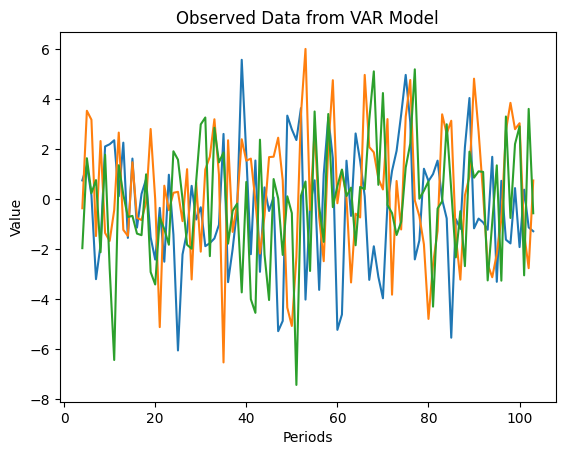

In [17]:
plt.plot(observed_data)
plt.title("Observed Data from VAR Model")
plt.xlabel("Periods")
plt.ylabel("Value")
plt.show()

### Generating the true IRFs

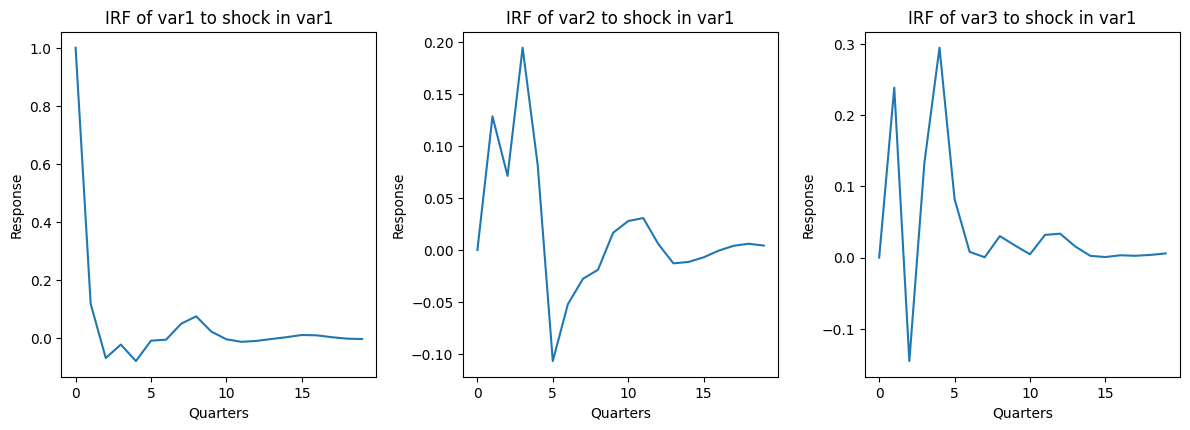

In [18]:
# true IRF from VAR process
# examine the response of each variable to a shock in variable 1, holding all else constant
# variable 1 is examined without loss of generality since the VAR process is symmetric across variables
true_irf = np.zeros((q, V, V))

shock = np.zeros(V)
shock[0] = 1 # shock variable 1
irf = np.zeros((q, V))
for t in range(q):
    if t == 0:
        irf[t] = shock
    else:
        for o in range(1, O+1):
            if t-o >= 0:
                irf[t] += A[o-1, :, :] @ irf[t-o]
true_irf[:, 0, :] = irf 

true_irf_df = pd.DataFrame(true_irf.reshape(q, V*V), columns=[f'var{j}_shock{i}' for i in range(1, V+1) for j in range(1, V+1)])

# plot the true IRFs to a shock in variable 1
plt.figure(figsize=(12, 8))
for i in range(V):
    plt.subplot(2, 3, i+1)
    plt.plot(true_irf[:, 0, i])
    plt.title(f'IRF of var{i+1} to shock in var1')
    plt.xlabel('Quarters')
    plt.ylabel('Response')
plt.tight_layout()
plt.show()

### Estimating the IRFs using smooth local projections